In this project, we collected data from various sources, cleaned, annotated and categorized them. In this notebook, we will conduct an exploratory data analysis of the collected text data.

In [13]:
import pandas as pd
from matplotlib import pyplot as plt
from wordcloud import WordCloud

In [37]:
# Location of the cleaned text data
filepath = "../../data/data-final-cleaned.pkl"
#df = pd.read_csv(filepath)
df = pd.read_pickle(filepath)

In [38]:
df.head()

,Source,Category,Headline,Description,Link,Date,Author,Target
0,Copperbelt Energy,career,"[CEC, Career, Opportunity, GDP, Legal]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 16:31:18+00:00,Lovejoy Musundire,0
1,Copperbelt Energy,career,"[CEC, Career, Opportunity, Assurance, Speciali...","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:15:28+00:00,Lovejoy Musundire,0
2,Copperbelt Energy,career,"[CEC, Career, Opportunity, Internal, Auditor, ...","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:14:39+00:00,Lovejoy Musundire,0
3,Copperbelt Energy,career,"[CEC, Career, Opportunity, Engineer, protection]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:41+00:00,Lovejoy Musundire,0
4,Copperbelt Energy,career,"[CEC, Career, Opportunity, Mechanic, II]","[currently, career, opportunity, follow, field...",https://cecinvestor.com/search/kitwe/feed/rss2/,2024-11-20 15:13:05+00:00,Lovejoy Musundire,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14282 entries, 0 to 14343
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   Source       14282 non-null  object             
 1   Category     14282 non-null  object             
 2   Headline     14282 non-null  object             
 3   Description  14282 non-null  object             
 4   Link         14282 non-null  object             
 5   Date         14282 non-null  datetime64[ns, UTC]
 6   Author       14282 non-null  object             
 7   Target       14282 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(6)
memory usage: 1004.2+ KB


In [40]:
df.shape

(14282, 8)

In [41]:
source_count = df['Source'].value_counts()
print(source_count)

Source
Lusaka Times               6479
Lusaka Voice               1745
Daily Nations Zambia       1361
Zambia Eye                 1022
Kitwe Online                889
Mwebantu                    711
Zambia Monitor              627
Copperbelt Energy           445
Zambian Eye                 300
Daily Revelation Zambia     202
Zambia365                   130
Zambia Reports              119
News Invasion 24             84
Lusaka Star                  67
ZNBC                         64
Flava FM                     14
DailyMail                    10
Tech Africa News              7
Christian Voice               4
Daily Mail Zambia             2
Name: count, dtype: int64


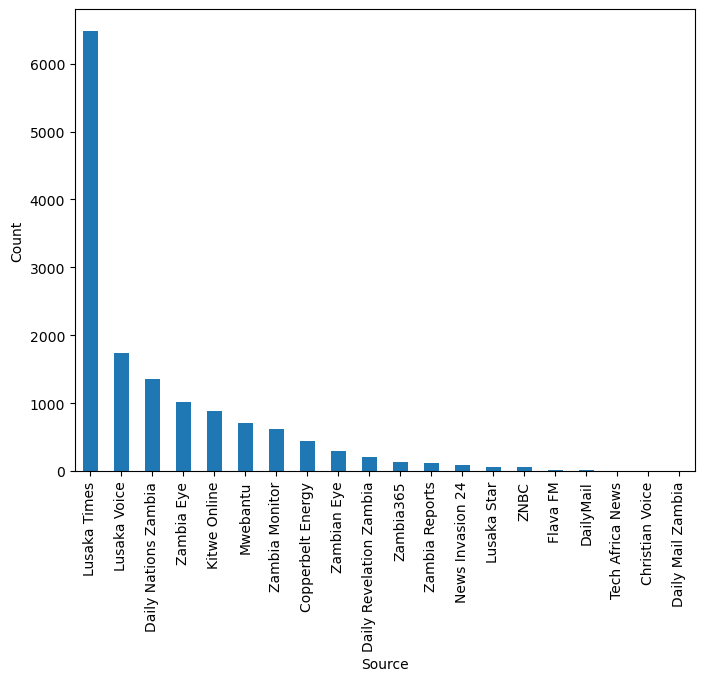

In [42]:
source_count.plot(kind="bar", figsize=(8,6))
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

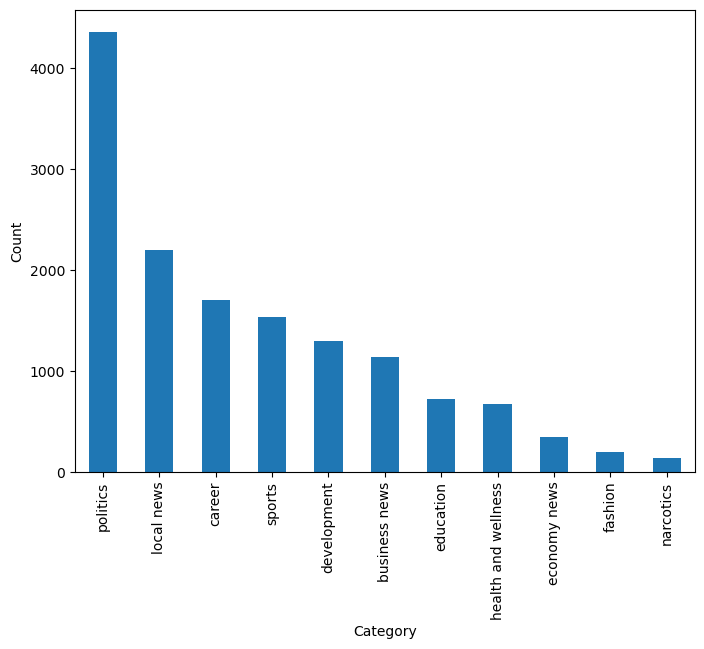

In [43]:
cat_count = df['Category'].value_counts()
cat_count.plot(kind="bar", figsize=(8,6))
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

Most of the news have been obtained from the Lusaka Times and the most of the news are from the politics and local news.

Target
1    8308
0    5974
Name: count, dtype: int64


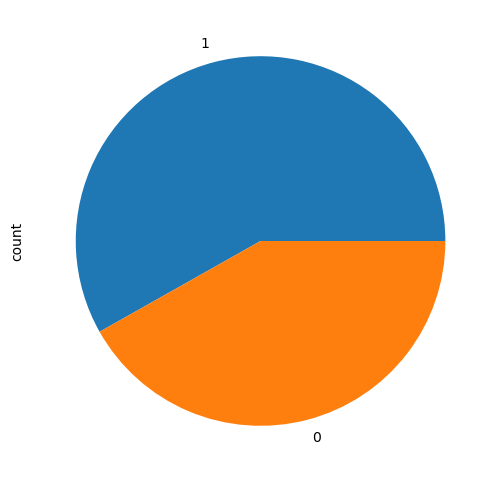

In [44]:
target_count = df['Target'].value_counts()
print(target_count)

target_count.plot.pie(figsize=(6,6))
plt.show()

Let's take a look at the word cloud from the text in the headline and descriptions:

In [55]:
comb_text = (df['Headline'] + df['Description']).apply(lambda x:" ".join(x))
print(comb_text)                    

0        CEC Career Opportunity GDP Legal currently car...
1        CEC Career Opportunity Assurance Specialist Sy...
2        CEC Career Opportunity Internal Auditor Inform...
3        CEC Career Opportunity Engineer protection cur...
4        CEC Career Opportunity Mechanic II currently c...
                               ...                        
14339    year OLD KITWE MAN arrest SEXUALLY abuse daugh...
14340    HH DIRECTS COPPERBELT PROVINCIAL ADMINISTRATIO...
14341    traffic police order rid ROADS INSANITY Michae...
14342    DEC ARRESTS LUSAKA COPPERBELT trafficking COCA...
14343    police officer CHILE family CLASH court KITWE ...
Length: 14282, dtype: object


In [65]:
comb_all = " ".join(comb_text)
#comb_all = comb_text.str.cat(sep=" ")
print(comb_all[:600])

CEC Career Opportunity GDP Legal currently career opportunity follow field GDP LEGAL Grade CEC GDP Contract Type fix Term location Kitwe fresh graduate Bachelor Law Degree LLB Advocate High Court Zambia seek acquire real world hand experience hone strength CEC Career Opportunity Assurance Specialist Systems currently career opportunity follow field ASSURANCE SPECIALIST SYSTEMS Grade CEC Contract Type Permanent location Kitwe role responsible implement strategic risk base internal audit plan assist functional head manage Assurance Internal Audit function accordance internal audit charter CEC Ca


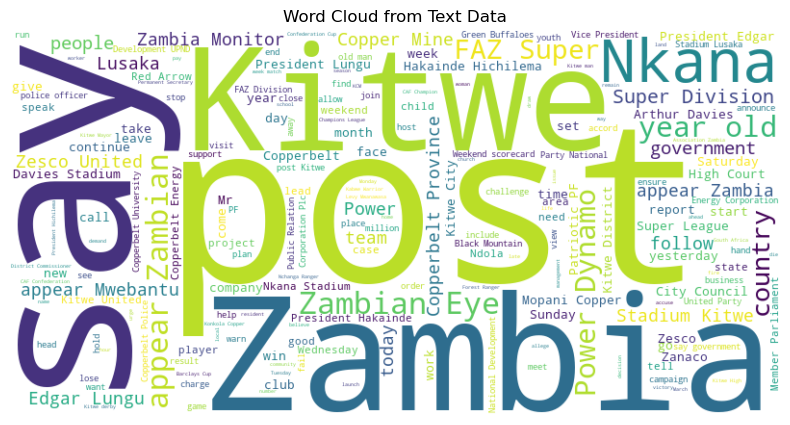

In [66]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(comb_all)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from Text Data')
plt.show()

The wordcloud shows the most frequenctly occured words in the news we collected so far which is Zambia, Kitwe and also Post, say (which I think needed some cleaning).

In [69]:
df.groupby(by="Category")['Target'].sum()

Category
business news           783
career                  696
development             809
economy news            210
education               456
fashion                  63
health and wellness     419
local news             1212
narcotics                84
politics               3007
sports                  569
Name: Target, dtype: int64

In [ ]:
news_per_date = df["Date"].value_counts()
news_per_date.plot(kind='line', figsize=(8,6))
#plt.show()